In [2]:
import sys
sys.path.append("..")
from berries.my_datasets import load_supervised_image 
from typing import NamedTuple
from jax import Array

class ImageClassification(NamedTuple):
    n_samples: int
    d_x: tuple[int, int]
    d_y: int
    n_channels: int
    X: Array
    y: Array
    X_test: Array
    y_test: Array

data: ImageClassification = load_supervised_image("mnist")


/home/cwhy/Projects/Jax/picojam/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from typing import List, Tuple, Optional, Any

Array = jnp.ndarray

def plot_image(image: Array, image_shape: Tuple[int, int], title: str = "Image", cmap: str = 'gray') -> None:
    """Plot a single image.
    
    Args:
        image: Image array of shape (height*width,)
        image_shape: Shape of the image as (height, width)
        title: Title for the plot
        cmap: Colormap to use
    """
    plt.figure(figsize=(4, 4))
    plt.imshow(image.reshape(image_shape), cmap=cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()

def plot_comparison(original: Array, generated: Array, image_shape: Tuple[int, int], 
                    titles: Tuple[str, str] = ('Original Image', 'Generated Image')) -> None:
    """Plot original and generated images side by side.
    
    Args:
        original: Original image array of shape (height*width,)
        generated: Generated image array of shape (height*width,)
        image_shape: Shape of the images as (height, width)
        titles: Tuple of titles for the plots
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original.reshape(image_shape), cmap='gray')
    axes[0].set_title(titles[0])
    axes[0].axis('off')

    axes[1].imshow(generated.reshape(image_shape), cmap='gray')
    axes[1].set_title(titles[1])
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

def plot_loss_history(loss_history: List[float], title: str = 'Training Loss') -> None:
    """Plot the training loss history.
    
    Args:
        loss_history: List of loss values
        title: Title for the plot
    """
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

def visualize_high_res(network_forward_fn, params: Any, resolution: int = 100, 
                       cmap: str = 'gray', title: Optional[str] = None) -> None:
    """Visualize the learned function at higher resolution.
    
    Args:
        network_forward_fn: Function that takes parameters and coordinates and returns predictions
        params: Network parameters to pass to network_forward_fn
        resolution: Resolution of the visualization
        cmap: Colormap to use
        title: Title for the plot, defaults to resolution-based title if None
    """
    # Create a fine grid for visualization
    y_coords = jnp.linspace(-1, 1, resolution)
    x_coords = jnp.linspace(-1, 1, resolution)
    xv, yv = jnp.meshgrid(x_coords, y_coords)
    vis_coords = jnp.stack([xv.flatten(), yv.flatten()], axis=1)
    
    # Generate predictions on the fine grid
    pred_fine = network_forward_fn(params, vis_coords)
    vis_img = pred_fine.reshape((resolution, resolution))
    
    # Plot
    plt.figure(figsize=(6, 6))
    plt.imshow(vis_img, cmap=cmap)
    if title is None:
        title = f'Generated Image at {resolution}x{resolution} Resolution'
    plt.title(title)
    plt.colorbar()
    plt.grid(False)
    plt.show()

def create_coordinate_grid(height: int, width: int) -> Array:
    """Create a normalized coordinate grid for the image.
    
    Args:
        height: Height of the image
        width: Width of the image
        
    Returns:
        Array of shape (height*width, 2) containing normalized (x,y) coordinates
    """
    y_coords = jnp.linspace(-1, 1, height)
    x_coords = jnp.linspace(-1, 1, width)
    xv, yv = jnp.meshgrid(x_coords, y_coords)
    coords = jnp.stack([xv.flatten(), yv.flatten()], axis=1)
    return coords


from typing import List, Tuple, Optional, Union, Any
import jax.numpy as jnp

Array = jnp.ndarray

def plot_image(image: Array, image_shape: Tuple[int, int], title: str = "Image", cmap: str = 'gray') -> None:
    """Plot a single image."""
    ...

def plot_comparison(original: Array, generated: Array, image_shape: Tuple[int, int], 
                    titles: Tuple[str, str] = ('Original Image', 'Generated Image')) -> None:
    """Plot original and generated images side by side."""
    ...

def plot_loss_history(loss_history: List[float], title: str = 'Training Loss') -> None:
    """Plot the training loss history."""
    ...

def visualize_high_res(network_forward_fn, params: Any, resolution: int = 100, 
                       cmap: str = 'gray', title: Optional[str] = None) -> None:
    """Visualize the learned function at higher resolution."""
    ...

def create_coordinate_grid(height: int, width: int) -> Array:
    """Create a normalized coordinate grid for the image."""
    ...


Dataset loaded: 60000 images of shape (28, 28)
Training on 50 images...
Epoch 0, Loss: 0.282654
Epoch 50, Loss: 0.272067
Epoch 100, Loss: 0.261822
Epoch 150, Loss: 0.251865
Epoch 200, Loss: 0.242162
Epoch 250, Loss: 0.232711
Epoch 300, Loss: 0.223466
Epoch 350, Loss: 0.214448
Epoch 400, Loss: 0.205726
Epoch 450, Loss: 0.197319
Epoch 500, Loss: 0.189249
Epoch 550, Loss: 0.181532
Epoch 600, Loss: 0.174177
Epoch 650, Loss: 0.167229
Epoch 700, Loss: 0.160607
Epoch 750, Loss: 0.154353
Epoch 800, Loss: 0.148454
Epoch 850, Loss: 0.142868
Epoch 900, Loss: 0.137577
Epoch 950, Loss: 0.132618
Epoch 1000, Loss: 0.127975
Epoch 1050, Loss: 0.123649
Epoch 1100, Loss: 0.119612
Epoch 1150, Loss: 0.115887
Epoch 1200, Loss: 0.112442
Epoch 1250, Loss: 0.109273
Epoch 1300, Loss: 0.106366
Epoch 1350, Loss: 0.103695
Epoch 1400, Loss: 0.101241
Epoch 1450, Loss: 0.098998
Epoch 1500, Loss: 0.096930
Epoch 1550, Loss: 0.095026
Epoch 1600, Loss: 0.093270
Epoch 1650, Loss: 0.091644
Epoch 1700, Loss: 0.090132
Epoch 

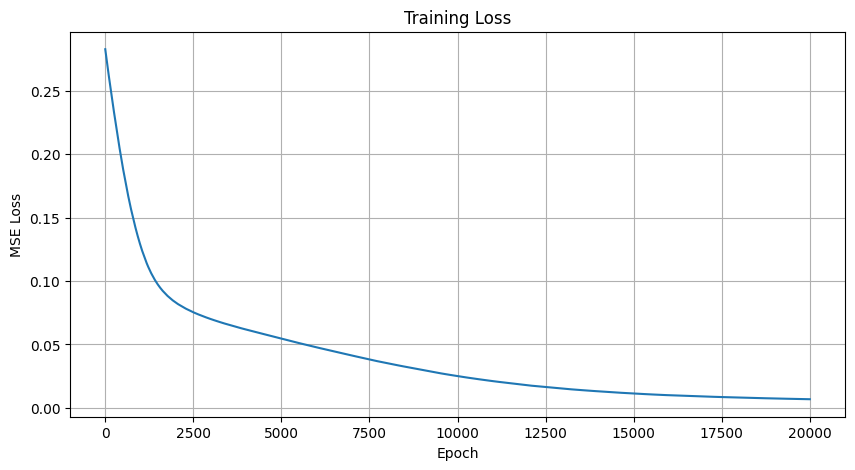

Visualizing positional embeddings...


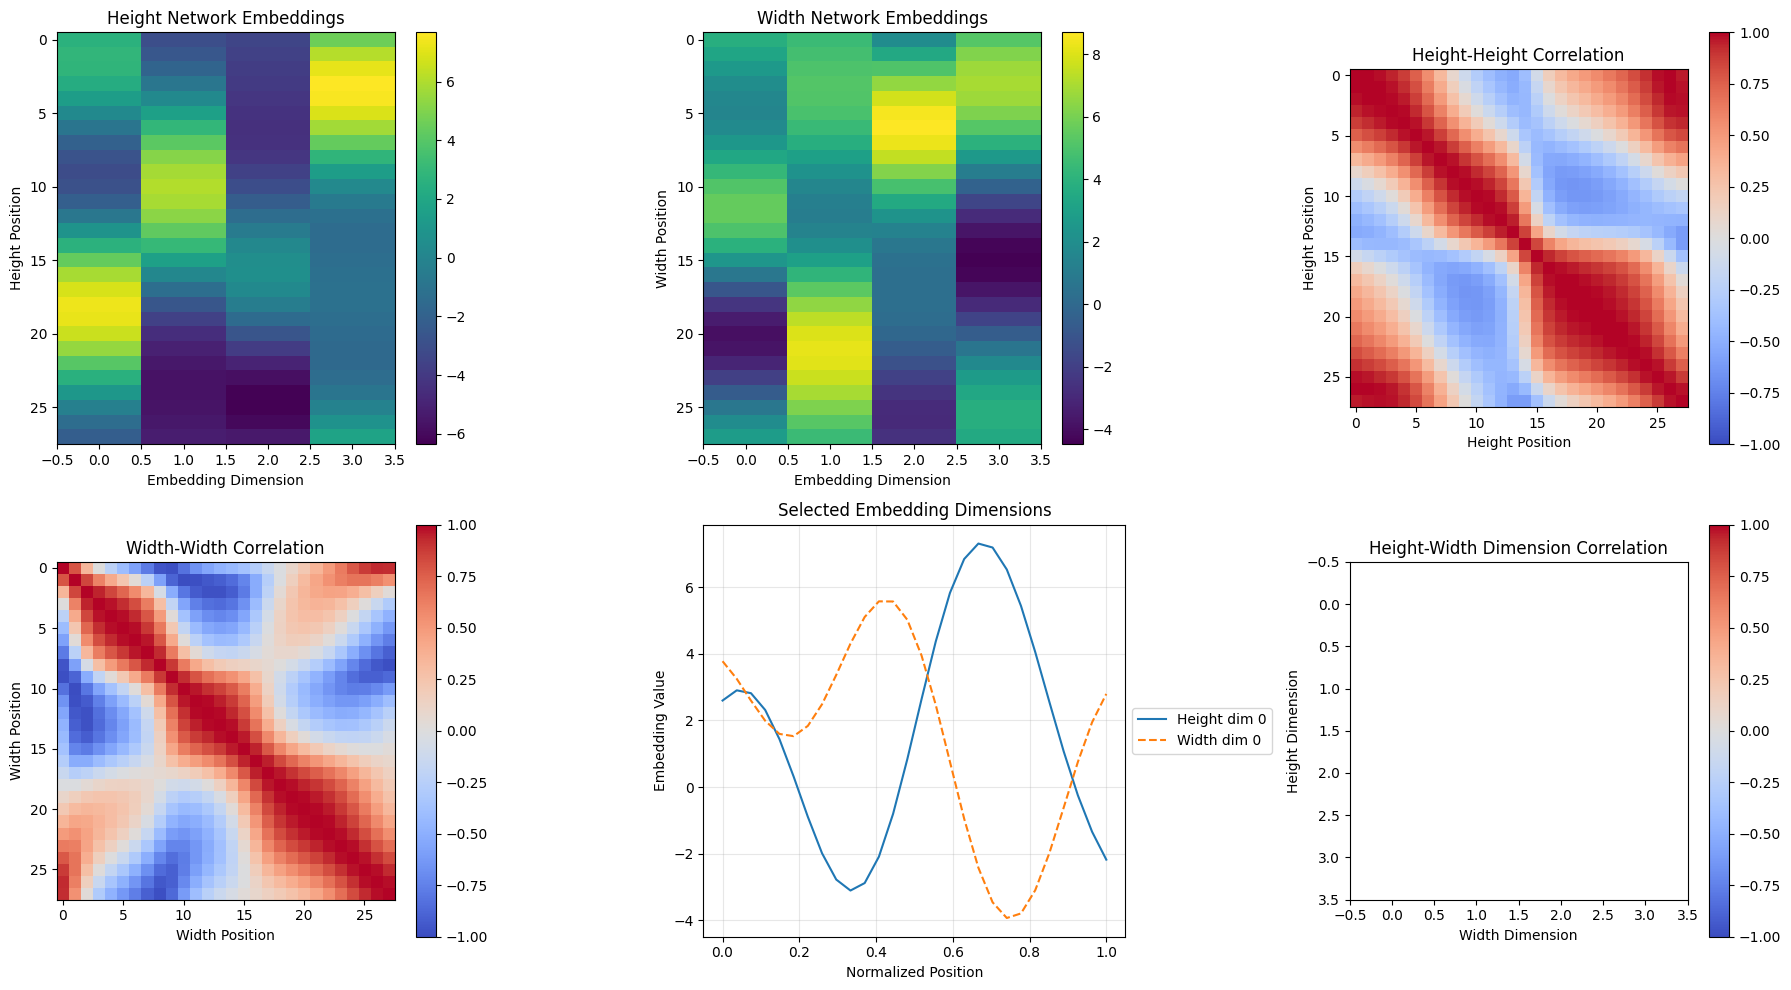

Visualizing embedding space...


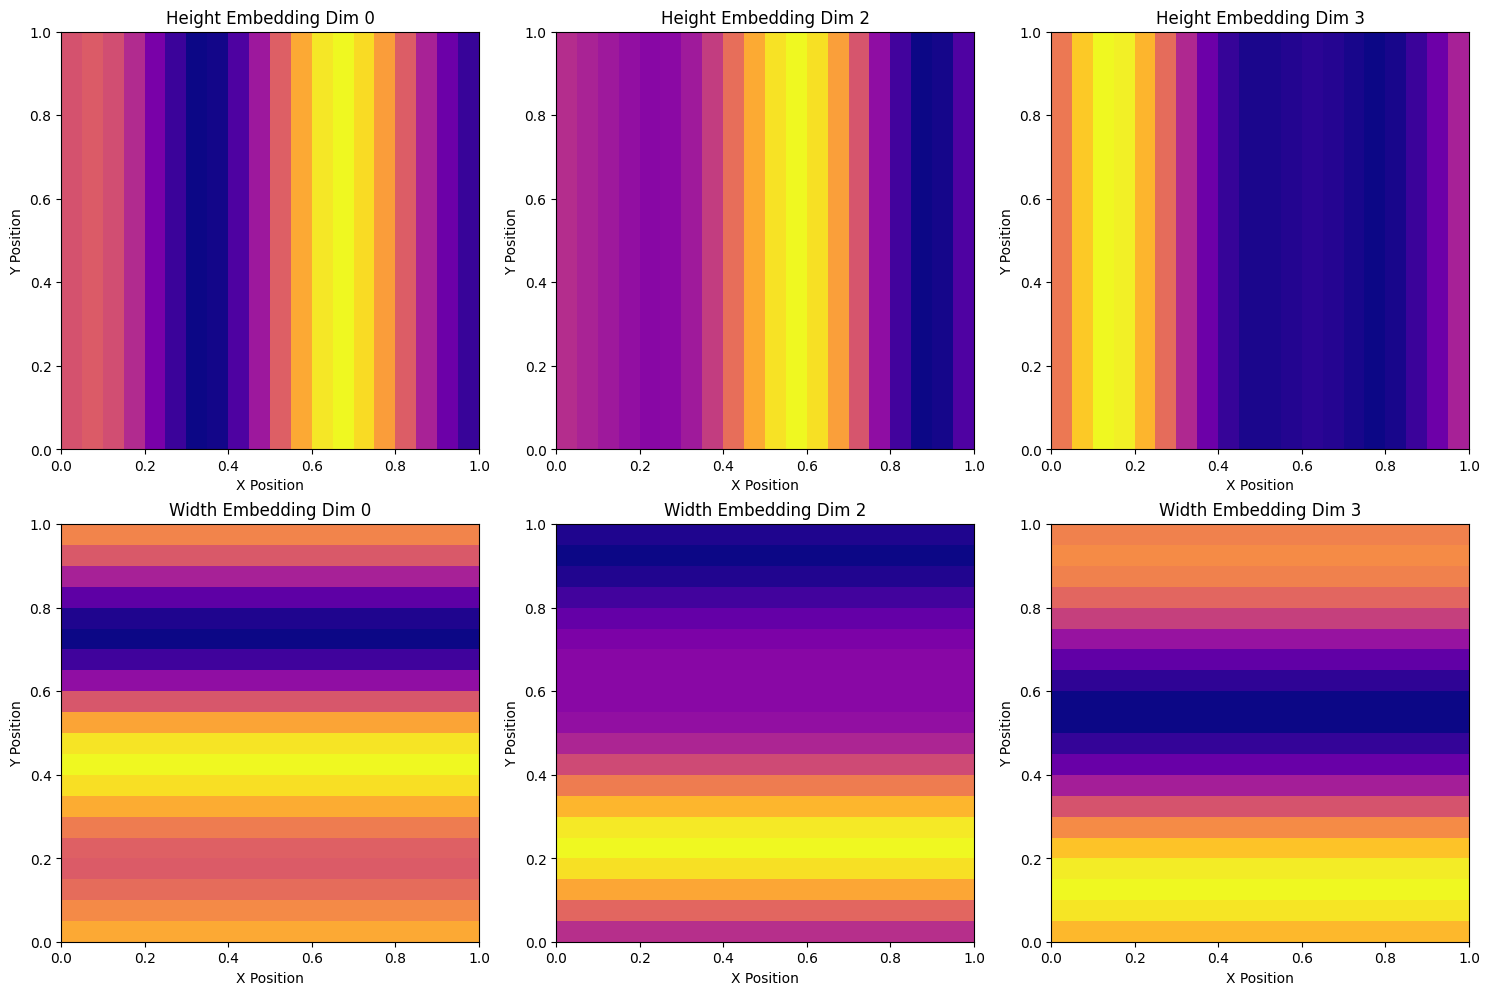

Reconstructing test images...


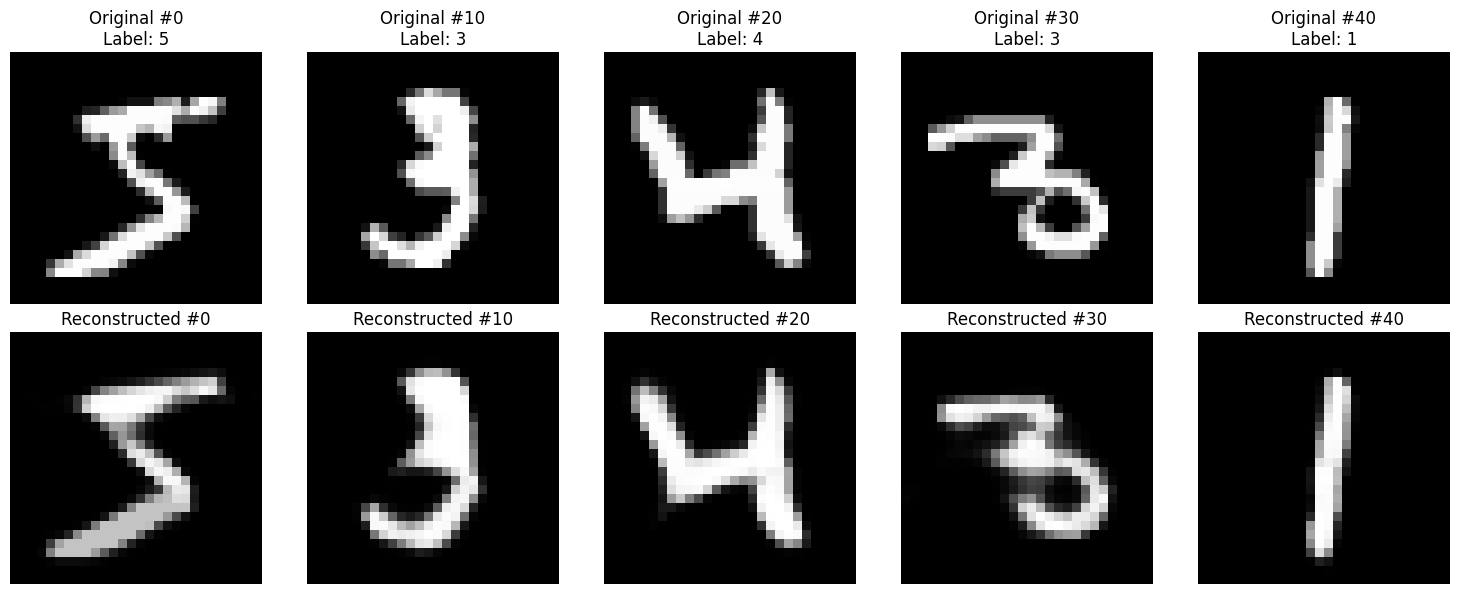

Analyzing image representations...


ValueError: 'c' argument has 100 elements, which is inconsistent with 'x' and 'y' with size 50.

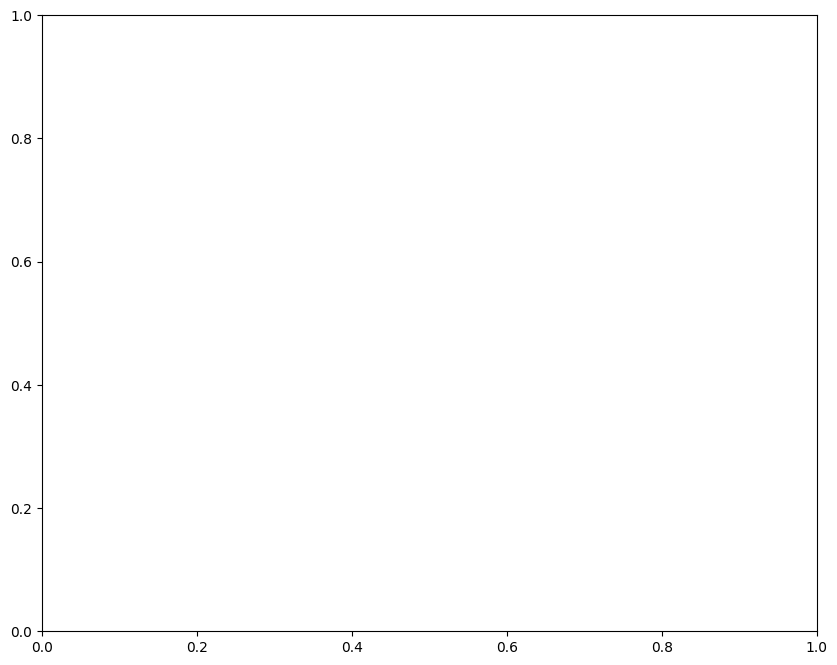

In [9]:
# Extract image dimensions
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt


height, width = data.d_x
print(f"Dataset loaded: {data.n_samples} images of shape {data.d_x}")

# Create coordinate indices for the entire image
def create_coordinate_indices(height, width):
    """Create coordinate indices for an image.
    
    Args:
        height: Image height
        width: Image width
    
    Returns:
        Array of shape (height*width, 2) with (y, x) coordinates
    """
    y_indices = jnp.arange(height)
    x_indices = jnp.arange(width)
    
    # Create meshgrid
    y_grid, x_grid = jnp.meshgrid(y_indices, x_indices, indexing='ij')
    
    # Reshape to (height*width, 2)
    coords = jnp.stack([y_grid.flatten(), x_grid.flatten()], axis=1)
    
    # Normalize to [0, 1]
    coords = coords.astype(jnp.float32)
    coords = coords / jnp.array([height - 1, width - 1])
    
    return coords

# Initialize positional embedding network parameters
def init_pos_network_params(key, hidden_dim=32, embed_dim=16):
    """Initialize parameters for a positional embedding network.
    
    Args:
        key: Random key for initialization
        hidden_dim: Hidden layer dimension
        embed_dim: Output embedding dimension
        
    Returns:
        Tuple of (W1, b1, W2, b2)
    """
    key1, key2 = jax.random.split(key)
    
    # Initialize weights for two layers (input is a single coordinate value)
    W1 = jax.random.normal(key1, (1, hidden_dim)) * jnp.sqrt(2.0) * 5 
    b1 = jnp.zeros((hidden_dim,))

    
    W2 = jax.random.normal(key2, (hidden_dim, embed_dim)) * jnp.sqrt(2.0 / hidden_dim)
    b2 = jnp.zeros((embed_dim,))
    
    return (W1, b1, W2, b2)

# Forward pass through positional embedding network
def pos_network_forward(params, x):
    """Forward pass through the positional embedding network.
    
    Args:
        params: Tuple of (W1, b1, W2, b2)
        x: Input array of shape (batch_size, 1) with coordinate values
        
    Returns:
        Output array of shape (batch_size, embed_dim)
    """
    W1, b1, W2, b2 = params
    
    # First layer with sine activation for better positional encoding
    h = jnp.dot(x, W1) + b1
    h = jnp.sin(h)  # Sine activation helps with smooth positional representations

    # Second layer with linear activation
    y = jnp.dot(h, W2) + b2
    
    return y

# Initialize MLP parameters
def init_mlp_params(key, input_dim, hidden_dim=64):
    """Initialize parameters for a small MLP.
    
    Args:
        key: Random key for initialization
        input_dim: Input dimension (2*embed_dim)
        hidden_dim: Hidden layer dimension
        
    Returns:
        Tuple of (W1, b1, W2, b2)
    """
    key1, key2 = jax.random.split(key)
    
    # Initialize weights for two layers
    W1 = jax.random.normal(key1, (input_dim, hidden_dim)) * jnp.sqrt(2.0 / input_dim)
    b1 = jnp.zeros((hidden_dim,))
    
    W2 = jax.random.normal(key2, (hidden_dim, 1)) * jnp.sqrt(2.0 / hidden_dim)
    b2 = jnp.zeros((1,))
    
    return (W1, b1, W2, b2)

# Initialize MLP parameters for all images at once
def init_all_mlp_params(key, num_images, input_dim, hidden_dim=64):
    """Initialize parameters for all image MLPs at once.
    
    Args:
        key: Random key for initialization
        num_images: Number of images to create parameters for
        input_dim: Input dimension (2*embed_dim)
        hidden_dim: Hidden layer dimension
        
    Returns:
        Dictionary with parameter matrices for all MLPs
        {
            'W1': Array of shape (num_images, input_dim, hidden_dim),
            'b1': Array of shape (num_images, hidden_dim),
            'W2': Array of shape (num_images, hidden_dim, 1),
            'b2': Array of shape (num_images, 1)
        }
    """
    # Generate keys for all images
    keys = jax.random.split(key, num_images)
    
    # Initialize parameters for each image
    all_W1 = []
    all_b1 = []
    all_W2 = []
    all_b2 = []
    
    for i in range(num_images):
        W1, b1, W2, b2 = init_mlp_params(keys[i], input_dim, hidden_dim)
        all_W1.append(W1)
        all_b1.append(b1)
        all_W2.append(W2)
        all_b2.append(b2)
    
    # Stack parameters into matrices
    mlp_params = {
        'W1': jnp.stack(all_W1),
        'b1': jnp.stack(all_b1),
        'W2': jnp.stack(all_W2),
        'b2': jnp.stack(all_b2)
    }
    
    return mlp_params



# Get positional embeddings for coordinates
def get_positional_embeddings(height_net_params, width_net_params, coords):
    """Get embeddings for coordinates using positional networks.
    
    Args:
        height_net_params: Parameters for height embedding network
        width_net_params: Parameters for width embedding network
        coords: Array of shape (batch_size, 2) with normalized (y, x) coordinates
    
    Returns:
        Array of shape (batch_size, 2*embed_dim) with concatenated embeddings
    """
    # Extract normalized y and x coordinates
    y_coords = coords[:, 0:1]  # Keep the dimension for matrix operations
    x_coords = coords[:, 1:2]
    
    # Get embeddings using the networks
    y_embeddings = pos_network_forward(height_net_params, y_coords)
    x_embeddings = pos_network_forward(width_net_params, x_coords)
    
    # Concatenate embeddings
    return jnp.concatenate([y_embeddings, x_embeddings], axis=1)

# Vectorized predict image pixels function for a batch of images
def predict_image(pos_params, mlp_param_matrix, img_idx, coords):
    """Predict pixel values for a batch of images using matrix parameters.
    
    Args:
        pos_params: Tuple of (height_net_params, width_net_params)
        mlp_params_matrix: Dictionary with parameter matrices for all MLPs
        coords: Coordinate indices (normalized)
        
    Returns:
        Predicted pixel values for all images in the batch
    """
    height_net_params, width_net_params = pos_params
    
    # Get positional embeddings (same for all images in batch)
    pos_embeddings = get_positional_embeddings(height_net_params, width_net_params, coords)
    
    # First layer with ReLU activation
    W1, b1, W2, b2 = mlp_param_matrix['W1'][img_idx], mlp_param_matrix['b1'][img_idx], \
        mlp_param_matrix['W2'][img_idx], mlp_param_matrix['b2'][img_idx]
    h = jnp.dot(pos_embeddings, W1) + b1
    h = jax.nn.relu(h)
    
    # Second layer with sigmoid activation for pixel values
    y = jnp.dot(h, W2) + b2
    y = jax.nn.sigmoid(y)
        
    return y

# Vectorized loss function for a batch of images
def compute_batch_loss(pos_params, mlp_params_matrix, coords, target_images_batch):
    """Compute average MSE loss for a batch of images.
    
    Args:
        pos_params: Tuple of (height_net_params, width_net_params)
        mlp_params_matrix: Dictionary with parameter matrices for all MLPs
        coords: Coordinate indices (normalized)
        target_images_batch: Batch of target image pixels
    
    Returns:
        Average MSE loss over the batch
    """
    height_net_params, width_net_params = pos_params
    
    # Get positional embeddings (same for all images in batch)
    pos_embeddings = get_positional_embeddings(height_net_params, width_net_params, coords)
    
    # Define a function that computes loss for a single image given its MLP params and target
    def single_image_loss(W1, b1, W2, b2, target_image):
        # First layer with ReLU activation
        h = jnp.dot(pos_embeddings, W1) + b1
        h = jax.nn.relu(h)
        
        # Second layer with sigmoid activation for pixel values
        y = jnp.dot(h, W2) + b2
        y = jax.nn.sigmoid(y)
        
        # Calculate mean squared error
        return jnp.mean((y.flatten() - target_image) ** 2)
    
    # Map the loss function over all parameters and targets
    losses = jax.vmap(single_image_loss)(
        target_image=target_images_batch, **mlp_params_matrix
    )
    
    # Return average loss
    return jnp.mean(losses)

# Training step function using vmap for efficiency
@jax.jit
def train_step(params, opt_state, coords, target_images_batch, batch_idx):
    """Perform a single training step for a batch of images.
    
    Args:
        params: Tuple of (pos_params, mlp_params_matrix)
        opt_state: Optimizer state
        coords: Coordinate indices (normalized)
        target_images_batch: Batch of target image pixels
        batch_idx: Integer representing the batch index (not individual image indices)
    
    Returns:
        Updated parameters, optimizer state, and loss value
    """
    
    # Define the loss function 
    def loss_fn(p):
        pos_p, mlp_p_matrix = p
        # Here we're using the entire matrix but computing loss only on the batch
        return compute_batch_loss(pos_p, mlp_p_matrix, coords, target_images_batch)
    
    # Compute gradients
    loss_value, grads = jax.value_and_grad(loss_fn)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_value

# Main training function
def train_model(params, coords, flattened_images, 
                num_epochs=200, batch_size=10, num_train_images=100):
    """Train the model on the dataset.
    
    Args:
        params: Initial model parameters (pos_params, mlp_params_matrix)
        coords: Coordinate indices (normalized)
        flattened_images: Flattened image data
        num_epochs: Number of training epochs
        batch_size: Number of images to process in each batch
        num_train_images: Total number of training images
        
    Returns:
        Trained parameters and loss history
    """
    opt_state = optimizer.init(params)
    loss_history = []
    
    # Number of batches
    num_batches = num_train_images // batch_size
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        # Shuffle the dataset
        permutation = np.random.permutation(num_train_images)
        # shuffled_images = flattened_images[permutation]
        shuffled_images = flattened_images[:num_train_images]  # For demonstration
        
        # Process each batch
        for batch in range(num_batches):
            # Get batch data
            start_idx = batch * batch_size
            end_idx = start_idx + batch_size
            batch_images = shuffled_images[start_idx:end_idx]
            
            # Train step (using batch index only)
            params, opt_state, loss = train_step(
                params, opt_state, coords, batch_images, batch)
            
            epoch_loss += loss
        
        # Average loss for the epoch
        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)
        
        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    return params, loss_history

# Visualize position embeddings and their correlations
def visualize_position_embeddings(height_net_params, width_net_params, height, width, embed_dim):
    """Visualize the learned positional embeddings from the networks.
    
    Args:
        height_net_params: Parameters for height embedding network
        width_net_params: Parameters for width embedding network
        height: Image height
        width: Image width
        embed_dim: Embedding dimension
    """
    # Generate normalized coordinate values
    height_coords = jnp.linspace(0, 1, height).reshape(-1, 1)
    width_coords = jnp.linspace(0, 1, width).reshape(-1, 1)
    
    # Compute embeddings for all positions
    height_embeddings = pos_network_forward(height_net_params, height_coords)
    width_embeddings = pos_network_forward(width_net_params, width_coords)
    
    # Create figure with multiple plots
    fig = plt.figure(figsize=(18, 10))
    grid = plt.GridSpec(2, 3, figure=fig)
    
    # 1. Plot height embeddings
    ax1 = fig.add_subplot(grid[0, 0])
    im1 = ax1.imshow(height_embeddings, aspect='auto', cmap='viridis')
    ax1.set_title('Height Network Embeddings')
    ax1.set_xlabel('Embedding Dimension')
    ax1.set_ylabel('Height Position')
    fig.colorbar(im1, ax=ax1)
    
    # 2. Plot width embeddings
    ax2 = fig.add_subplot(grid[0, 1])
    im2 = ax2.imshow(width_embeddings, aspect='auto', cmap='viridis')
    ax2.set_title('Width Network Embeddings')
    ax2.set_xlabel('Embedding Dimension')
    ax2.set_ylabel('Width Position')
    fig.colorbar(im2, ax=ax2)
    
    # 3. Compute and plot height-height correlation matrix
    ax3 = fig.add_subplot(grid[0, 2])
    height_corr = np.corrcoef(height_embeddings)
    im3 = ax3.imshow(height_corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax3.set_title('Height-Height Correlation')
    ax3.set_xlabel('Height Position')
    ax3.set_ylabel('Height Position')
    fig.colorbar(im3, ax=ax3)
    
    # 4. Compute and plot width-width correlation matrix
    ax4 = fig.add_subplot(grid[1, 0])
    width_corr = np.corrcoef(width_embeddings)
    im4 = ax4.imshow(width_corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax4.set_title('Width-Width Correlation')
    ax4.set_xlabel('Width Position')
    ax4.set_ylabel('Width Position')
    fig.colorbar(im4, ax=ax4)
    
    # 5. Plot selected embedding dimensions across positions
    ax5 = fig.add_subplot(grid[1, 1])
    
    # Plot a few dimensions for height
    for i in range(0, embed_dim, 4):  # Plot every 4th dimension
        ax5.plot(height_coords, height_embeddings[:, i], 
                 label=f'Height dim {i}', linestyle='-')
    
    # Plot a few dimensions for width
    for i in range(0, embed_dim, 4):  # Plot every 4th dimension
        ax5.plot(width_coords, width_embeddings[:, i], 
                 label=f'Width dim {i}', linestyle='--')
    
    ax5.set_title('Selected Embedding Dimensions')
    ax5.set_xlabel('Normalized Position')
    ax5.set_ylabel('Embedding Value')
    ax5.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax5.grid(True, alpha=0.3)
    
    # 6. Cross-correlation between dimensions
    ax6 = fig.add_subplot(grid[1, 2])
    
    # Compute correlation between embedding dimensions
    dim_corr = np.zeros((embed_dim, embed_dim))
    for i in range(embed_dim):
        for j in range(embed_dim):
            # Use middle positions from both dimensions for correlation
            h_mid = height_embeddings[height // 2, i]
            w_vals = width_embeddings[:, j]
            # Correlation between one height position and all width positions
            corr = np.corrcoef(h_mid * np.ones_like(w_vals), w_vals)[0, 1]
            dim_corr[i, j] = corr
    
    im6 = ax6.imshow(dim_corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax6.set_title('Height-Width Dimension Correlation')
    ax6.set_xlabel('Width Dimension')
    ax6.set_ylabel('Height Dimension')
    fig.colorbar(im6, ax=ax6)
    
    plt.tight_layout()
    plt.show()

# Sample specific coordinates to visualize embedding space
def visualize_embedding_space(height_net_params, width_net_params, embed_dim):
    """Visualize the embedding space by plotting selected dimensions.
    
    Args:
        height_net_params: Parameters for height embedding network
        width_net_params: Parameters for width embedding network
        embed_dim: Embedding dimension
    """
    # Generate a grid of coordinates
    num_points = 20
    y_vals = np.linspace(0, 1, num_points)
    x_vals = np.linspace(0, 1, num_points)
    
    # Create meshgrid
    y_grid, x_grid = np.meshgrid(y_vals, x_vals)
    
    # Create coordinate arrays for each position
    y_coords = y_grid.flatten().reshape(-1, 1)  # Shape: (num_points*num_points, 1)
    x_coords = x_grid.flatten().reshape(-1, 1)  # Shape: (num_points*num_points, 1)
    
    # Compute embeddings for all points
    # Apply function to each coordinate (no reshaping needed as they're already correctly shaped)
    y_embeddings = jax.vmap(lambda y: pos_network_forward(height_net_params, y))(y_coords)
    x_embeddings = jax.vmap(lambda x: pos_network_forward(width_net_params, x))(x_coords)
    
    # Select dimensions to visualize
    dims_to_vis = [0, embed_dim // 2, embed_dim - 1]  # First, middle, last
    
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot each selected dimension
    for i, dim in enumerate(dims_to_vis):
        # Reshape embeddings for visualization
        y_dim = y_embeddings[:, dim].reshape(num_points, num_points)
        axes[0, i].imshow(y_dim, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
        axes[0, i].set_title(f'Height Embedding Dim {dim}')
        axes[0, i].set_xlabel('X Position')
        axes[0, i].set_ylabel('Y Position')
        
        x_dim = x_embeddings[:, dim].reshape(num_points, num_points)
        axes[1, i].imshow(x_dim, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
        axes[1, i].set_title(f'Width Embedding Dim {dim}')
        axes[1, i].set_xlabel('X Position')
        axes[1, i].set_ylabel('Y Position')
    
    plt.tight_layout()
    plt.show()

# Reconstruct and plot images
def reconstruct_images(height_net_params, width_net_params, mlp_params_matrix, coords, image_indices, height, width):
    """Reconstruct and plot selected images.
    
    Args:
        height_net_params: Parameters for height embedding network
        width_net_params: Parameters for width embedding network
        mlp_params_matrix: Dictionary with parameter matrices for all MLPs
        coords: Coordinate indices (normalized)
        image_indices: Indices of images to reconstruct
        height: Image height
        width: Image width
    """
    num_images = len(image_indices)
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 3, 6))
    
    for i, img_idx in enumerate(image_indices):
        # Get original image
        original = data.X[img_idx].reshape(height, width)
        
        # Predict image
        predictions = predict_image(
            (height_net_params, width_net_params), mlp_params_matrix, img_idx, coords)
        reconstructed = predictions.reshape(height, width)
        
        # Plot original
        axes[0, i].imshow(original, cmap='gray')
        axes[0, i].set_title(f"Original #{img_idx}\nLabel: {data.y[img_idx]}")
        axes[0, i].axis('off')
        
        # Plot reconstructed
        axes[1, i].imshow(reconstructed, cmap='gray')
        axes[1, i].set_title(f"Reconstructed #{img_idx}")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Analyze the learned representations
def analyze_image_representations(mlp_params_matrix, num_images=100):
    """Analyze the learned representations by comparing MLP weights.
    
    Args:
        mlp_params_matrix: Dictionary with parameter matrices for all MLPs
        num_images: Number of images to analyze
    """
    # Extract the second layer weights from each MLP
    W2_matrix = mlp_params_matrix['W2'][:num_images]
    
    # Flatten each W2 matrix
    representations = W2_matrix.reshape(W2_matrix.shape[0], -1)
    
    # Get labels
    labels = data.y[:num_images]
    
    # PCA for visualization (simple implementation)
    mean_rep = np.mean(representations, axis=0)
    centered = representations - mean_rep
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    reduced = U[:, :2] * S[:2]
    
    # Plot the representations colored by digit class
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='tab10', 
                         alpha=0.8, s=50)
    plt.colorbar(scatter, label='Digit Class')
    plt.title('MLP Representations Visualization (PCA)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True, alpha=0.3)
    plt.show()

# Main execution
if __name__ == "__main__":
    # Create coordinate indices (normalized)
    coords = create_coordinate_indices(height, width)

    # Hyperparameters
    embed_dim = 4
    hidden_dim = 8
    pos_hidden_dim = 8
    num_train_images = 50 # Subset for demonstration
    batch_size = 50
    num_epochs = 20000
    learning_rate = 1e-4

    # Initialize models
    key = jax.random.PRNGKey(42)
    height_key, width_key, mlp_key = jax.random.split(key, 3)

    # Initialize positional embedding networks
    height_net_params = init_pos_network_params(height_key, hidden_dim=pos_hidden_dim, embed_dim=embed_dim)
    width_net_params = init_pos_network_params(width_key, hidden_dim=pos_hidden_dim, embed_dim=embed_dim)
    
    # Combined positional parameters
    pos_params = (height_net_params, width_net_params)

    # Initialize MLP parameters for all images as a matrix
    mlp_params_matrix = init_all_mlp_params(mlp_key, num_train_images, input_dim=2*embed_dim, hidden_dim=hidden_dim)

    # Combine all parameters
    params = (pos_params, mlp_params_matrix)

    # Create optimizer
    optimizer = optax.adam(learning_rate)

    # Flatten images
    flattened_images = data.X.reshape(data.n_samples, -1) / 255.0  # Normalize pixel values to [0, 1]

    # Train the model
    print(f"Training on {num_train_images} images...")
    trained_params, loss_history = train_model(
        params, coords, flattened_images, 
        num_epochs=num_epochs, batch_size=batch_size, num_train_images=num_train_images)

    # Extract trained parameters
    trained_pos_params, trained_mlp_params_matrix = trained_params
    trained_height_net_params, trained_width_net_params = trained_pos_params

    # Plot loss history
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True)
    plt.show()

    # Visualize position embeddings
    print("Visualizing positional embeddings...")
    visualize_position_embeddings(
        trained_height_net_params, trained_width_net_params, height, width, embed_dim)
    
    # Visualize embedding space
    print("Visualizing embedding space...")
    visualize_embedding_space(trained_height_net_params, trained_width_net_params, embed_dim)

    # Reconstruct and plot some images
    test_indices = [0, 10, 20, 30, 40]  # Choose some images to reconstruct
    print("Reconstructing test images...")
    reconstruct_images(
        trained_height_net_params, trained_width_net_params, 
        trained_mlp_params_matrix, coords, test_indices, height, width)

    # Analyze the learned representations
    print("Analyzing image representations...")
    analyze_image_representations(trained_mlp_params_matrix)

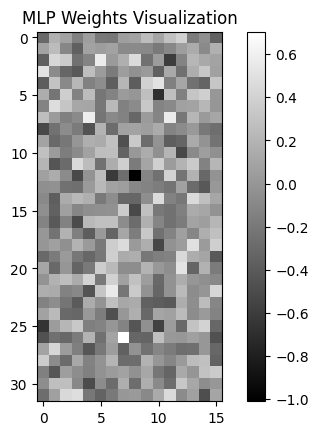

Text(0.5, 1.0, 'MLP Weights Visualization')

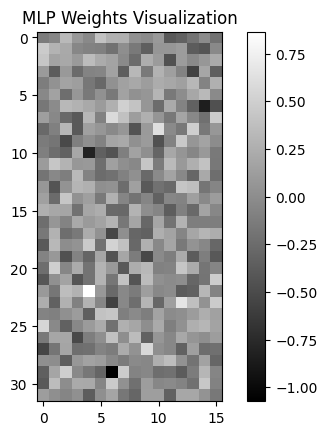

In [134]:
plt.imshow(mlp_params_matrix['W1'][0], cmap='gray')
plt.colorbar()
plt.title('MLP Weights Visualization')
plt.show()
plt.imshow(mlp_params_matrix['W1'][1], cmap='gray')
plt.colorbar()
plt.title('MLP Weights Visualization')